In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 中文字体
plt.rcParams['axes.unicode_minus'] = False  # 使用ASCII减号替代unicode减号

In [15]:
source_data = pd.read_csv('./data/2026_MCM_Problem_C_Data.csv')

In [16]:
source_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 53 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   celebrity_name                421 non-null    object 
 1   ballroom_partner              421 non-null    object 
 2   celebrity_industry            421 non-null    object 
 3   celebrity_homestate           365 non-null    object 
 4   celebrity_homecountry/region  421 non-null    object 
 5   celebrity_age_during_season   421 non-null    int64  
 6   season                        421 non-null    int64  
 7   results                       421 non-null    object 
 8   placement                     421 non-null    int64  
 9   week1_judge1_score            421 non-null    float64
 10  week1_judge2_score            421 non-null    float64
 11  week1_judge3_score            407 non-null    float64
 12  week1_judge4_score            81 non-null     float64
 13  week2

In [17]:
source_data.head()

,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,season,results,placement,week1_judge1_score,...,week9_judge3_score,week9_judge4_score,week10_judge1_score,week10_judge2_score,week10_judge3_score,week10_judge4_score,week11_judge1_score,week11_judge2_score,week11_judge3_score,week11_judge4_score
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,1,Eliminated Week 4,4,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,1,3rd Place,3,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
source_data['season'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34])

### 新增淘汰周、总分数列

In [19]:
# # 遍历所有周次的judge4列，如果为空则用对应周次的judge1、2、3的平均值填充
# for week_num in range(1, 12):  # 从week1到week11
#     judge4_col = f'week{week_num}_judge4_score'
#     judge1_col = f'week{week_num}_judge1_score'
#     judge2_col = f'week{week_num}_judge2_score'
#     judge3_col = f'week{week_num}_judge3_score'
#
#     # 检查列是否存在
#     if judge4_col in source_data.columns:
#         # 创建一个布尔索引，标识judge4_score为空的位置
#         mask = source_data[judge4_col].isna()
#
#         # 计算相同周次的judge1、2、3的平均值
#         judges_avg = source_data[[judge1_col, judge2_col, judge3_col]].mean(axis=1)
#
#         # 只对judge4为空的位置进行填充
#         source_data.loc[mask, judge4_col] = judges_avg[mask]

In [20]:
# 在创建elim_week列之后
def find_last_week_with_scores(row):
    for week_num in range(11, 0, -1):
        judge_cols = [f'week{week_num}_judge{j}_score' for j in range(1, 5)]
        existing_cols = [col for col in judge_cols if col in source_data.columns]
        if existing_cols and any(pd.notna(row[col]) and row[col] != 0 for col in existing_cols):
            return week_num
    return 0

source_data['elim_week'] = source_data.apply(find_last_week_with_scores, axis=1)

#1st Place的存活周+1
source_data.loc[source_data['results'] == '1st Place', 'elim_week'] += 1

# 标记规则组
source_data['rule_group'] = source_data['season'].apply(lambda s: 'percent' if 3<=s<=27 else 'rank')
source_data['is_s28_plus'] = (source_data['season'] >= 28)


source_data

,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,season,results,placement,week1_judge1_score,...,week10_judge2_score,week10_judge3_score,week10_judge4_score,week11_judge1_score,week11_judge2_score,week11_judge3_score,week11_judge4_score,elim_week,rule_group,is_s28_plus
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,rank,False
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,rank,False
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,rank,False
3,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,1,Eliminated Week 4,4,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,rank,False
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,1,3rd Place,3,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,rank,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,Scott Hoying,Rylee Arnold,Singer/Rapper,California,United States,34,34,Eliminated Week 6,10,5.0,...,0.0,0.0,NaN,0.0000,0.0000,0.0,NaN,6,rank,True
417,Alix Earle,Val Chmerkovskiy (Joey Graziadei week 9),Social media personality,Florida,United States,24,34,2nd Place,2,7.0,...,10.0,9.5,NaN,10.0000,10.0000,10.0,NaN,11,rank,True
418,Jen Affleck,Jan Ravnik,TV Personality,Utah,United States,26,34,Eliminated Week 7,9,6.0,...,0.0,0.0,NaN,0.0000,0.0000,0.0,NaN,7,rank,True
419,Whitney Leavitt,Mark Ballas,TV Personality,Utah,United States,32,34,Eliminated Week 10,6,7.0,...,10.0,10.0,NaN,0.0000,0.0000,0.0,NaN,10,rank,True


In [21]:
# 计算决赛周

def find_final_week_per_season_v2(df):
    """
    计算每个赛季的决赛周（简化版）
    """
    df['final_week'] = 0

    for season_num in df['season'].unique():
        season_data = df[df['season'] == season_num]

        # 找到该赛季每个参赛者最后有评分的周
        max_week_with_scores = 0
        for week_num in range(11, 0, -1):
            judge_cols = [f'week{week_num}_judge{j}_score' for j in range(1, 5)
                         if f'week{week_num}_judge{j}_score' in df.columns]

            if judge_cols:
                # 检查该周是否有任何参赛者有非零非空评分
                week_data = season_data[judge_cols]
                # 将数据展开成一维，检查是否有非零非空值
                flat_scores = week_data.values.flatten()
                valid_scores = [s for s in flat_scores if pd.notna(s) and s != 0]

                if len(valid_scores) > 0:  # 如果该周有任何有效评分
                    max_week_with_scores = week_num
                    break

        # 决赛周 = 最后有评分的周 + 1
        final_week = max_week_with_scores + 1 if max_week_with_scores > 0 else 1
        df.loc[df['season'] == season_num, 'final_week'] = final_week

    return df

# 应用函数计算决赛周

source_data = find_final_week_per_season_v2(source_data)

source_data['is_winner'] = source_data['results'] == '1st Place'


In [22]:
# # 从原始数据中移除所有judge4_score列
# columns_to_drop = [col for col in source_data.columns if 'judge4_score' in col]
# source_data = source_data.drop(columns=columns_to_drop)
#
# print(f"已移除 {len(columns_to_drop)} 个judge4_score列")
# print("被移除的列:", columns_to_drop)

# 重新计算每周的评分总和（仅使用前3个评委）
for week_num in range(1, 13):  # 从week1到week11
    # 定义当前周的前三个评委列
    judge_cols = [f'week{week_num}_judge1_score',
                  f'week{week_num}_judge2_score',
                  f'week{week_num}_judge3_score',
                  f'week{week_num}_judge4_score'
                  ]

    # 检查这些列是否存在于数据中
    existing_cols = [col for col in judge_cols if col in source_data.columns]

    # 计算每周总分（跳过缺失值）
    source_data[f'week{week_num}_total'] = source_data[existing_cols].sum(axis=1, skipna=True)

source_data.to_csv('./data/source_data.csv')
source_data

,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,season,results,placement,week1_judge1_score,...,week3_total,week4_total,week5_total,week6_total,week7_total,week8_total,week9_total,week10_total,week11_total,week12_total
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2,7.0,...,24.0,21.0,27.0,27.0,0.0,0.0,0.0,0.0,0.0000,0.0
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1,5.0,...,21.0,26.0,23.5,27.5,0.0,0.0,0.0,0.0,0.0000,0.0
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5,5.0,...,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0
3,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,1,Eliminated Week 4,4,7.0,...,26.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,1,3rd Place,3,7.0,...,22.0,20.0,22.5,0.0,0.0,0.0,0.0,0.0,0.0000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,Scott Hoying,Rylee Arnold,Singer/Rapper,California,United States,34,34,Eliminated Week 6,10,5.0,...,22.0,21.0,30.0,28.0,0.0,0.0,0.0,0.0,0.0000,0.0
417,Alix Earle,Val Chmerkovskiy (Joey Graziadei week 9),Social media personality,Florida,United States,24,34,2nd Place,2,7.0,...,23.0,24.0,35.0,35.0,43.0,38.5,40.0,29.0,30.0000,0.0
418,Jen Affleck,Jan Ravnik,TV Personality,Utah,United States,26,34,Eliminated Week 7,9,6.0,...,19.0,23.0,29.0,32.0,34.0,0.0,0.0,0.0,0.0000,0.0
419,Whitney Leavitt,Mark Ballas,TV Personality,Utah,United States,32,34,Eliminated Week 10,6,7.0,...,24.0,25.0,33.0,39.0,42.0,39.5,42.0,29.0,0.0000,0.0


### Melt

In [23]:
# 步骤1：准备id列（保留选手关键信息）
id_vars = ['celebrity_name', 'ballroom_partner', 'celebrity_industry','celebrity_homestate','results',
           'celebrity_homecountry/region','celebrity_age_during_season', 'season', 'elim_week',
           'final_week','is_winner','is_s28_plus']

# 步骤2：融化每周总分列（核心！）
value_vars = [f'week{w}_total' for w in range(1, 12) if f'week{w}_total' in source_data.columns]
df_long = source_data.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='week_col',  # 临时列：如"week3_total"
    value_name='J'        # 评委总分
)

# 步骤3：清洗周次编号 + 标记状态
df_long['week_num'] = df_long['week_col'].str.extract(r'week(\d+)_total').astype(int)

# 判断是否还在比赛中
df_long['in_competition'] = df_long['week_num'] <= df_long['elim_week']

# 修正淘汰标记：冠军（results为'1st Place'）即使在决赛周也不标记为淘汰
df_long['is_eliminated'] = (
    (df_long['week_num'] == df_long['elim_week']) &
    (df_long['results'] != '1st Place')
)

# 首先确保df_long中有rule_group列（需要从source_data合并过来）
df_long = df_long.merge(
    source_data[['season', 'rule_group']].drop_duplicates(),
    on='season',
    how='left'
)


In [24]:
df_long

,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,results,celebrity_homecountry/region,celebrity_age_during_season,season,elim_week,final_week,is_winner,is_s28_plus,week_col,J,week_num,in_competition,is_eliminated,rule_group
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,2nd Place,United States,50,1,6,7,False,False,week1_total,20.0000,1,True,False,rank
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,1st Place,United States,29,1,7,7,True,False,week1_total,13.0000,1,True,False,rank
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,Eliminated Week 3,United States,42,1,3,7,False,False,week1_total,18.0000,1,True,False,rank
3,Rachel Hunter,Jonathan Roberts,Model,NaN,Eliminated Week 4,New Zealand,35,1,4,7,False,False,week1_total,20.0000,1,True,False,rank
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,3rd Place,United States,32,1,5,7,False,False,week1_total,20.0000,1,True,False,rank
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4626,Scott Hoying,Rylee Arnold,Singer/Rapper,California,Eliminated Week 6,United States,34,34,6,12,False,True,week11_total,0.0000,11,False,False,rank
4627,Alix Earle,Val Chmerkovskiy (Joey Graziadei week 9),Social media personality,Florida,2nd Place,United States,24,34,11,12,False,True,week11_total,30.0000,11,True,True,rank
4628,Jen Affleck,Jan Ravnik,TV Personality,Utah,Eliminated Week 7,United States,26,34,7,12,False,True,week11_total,0.0000,11,False,False,rank
4629,Whitney Leavitt,Mark Ballas,TV Personality,Utah,Eliminated Week 10,United States,32,34,10,12,False,True,week11_total,0.0000,11,False,False,rank


### 预计算归一化评委分（仅针对rank组）

In [25]:
df_long['J_min'] = df_long.groupby(['season','week_num'])['J'].transform('min')
df_long['J_max'] = df_long.groupby(['season','week_num'])['J'].transform('max')

# 仅对rank组进行归一化，percent组保持原值
df_long['norm_J'] = df_long['J']  # 默认为原值
mask_rank = df_long['rule_group'] == 'rank'  # 筛选rank组数据
df_long.loc[mask_rank, 'norm_J'] = (
    (df_long.loc[mask_rank, 'J'] - df_long.loc[mask_rank, 'J_min']) /
    (df_long.loc[mask_rank, 'J_max'] - df_long.loc[mask_rank, 'J_min'] + 1e-8)
)

df_long['is_final_week'] = df_long['week_num'] == df_long.groupby('season')['elim_week'].transform('max')
# 计算本周淘汰人数
elim_count = df_long.groupby(['season','week_num'])['is_eliminated'].sum()
df_long['elim_count'] = df_long.set_index(['season','week_num']).index.map(elim_count)

df_long = df_long.drop(columns=['week_col','J_min','J_max','final_week'])  # 清理临时列

df_long.info()
df_long.to_csv('./data/df_long.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4631 entries, 0 to 4630
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   celebrity_name                4631 non-null   object 
 1   ballroom_partner              4631 non-null   object 
 2   celebrity_industry            4631 non-null   object 
 3   celebrity_homestate           4015 non-null   object 
 4   results                       4631 non-null   object 
 5   celebrity_homecountry/region  4631 non-null   object 
 6   celebrity_age_during_season   4631 non-null   int64  
 7   season                        4631 non-null   int64  
 8   elim_week                     4631 non-null   int64  
 9   is_winner                     4631 non-null   bool   
 10  is_s28_plus                   4631 non-null   bool   
 11  J                             4631 non-null   float64
 12  week_num                      4631 non-null   int64  
 13  in_

C:\Users\L\AppData\Local\Temp\ipykernel_17228\891196184.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


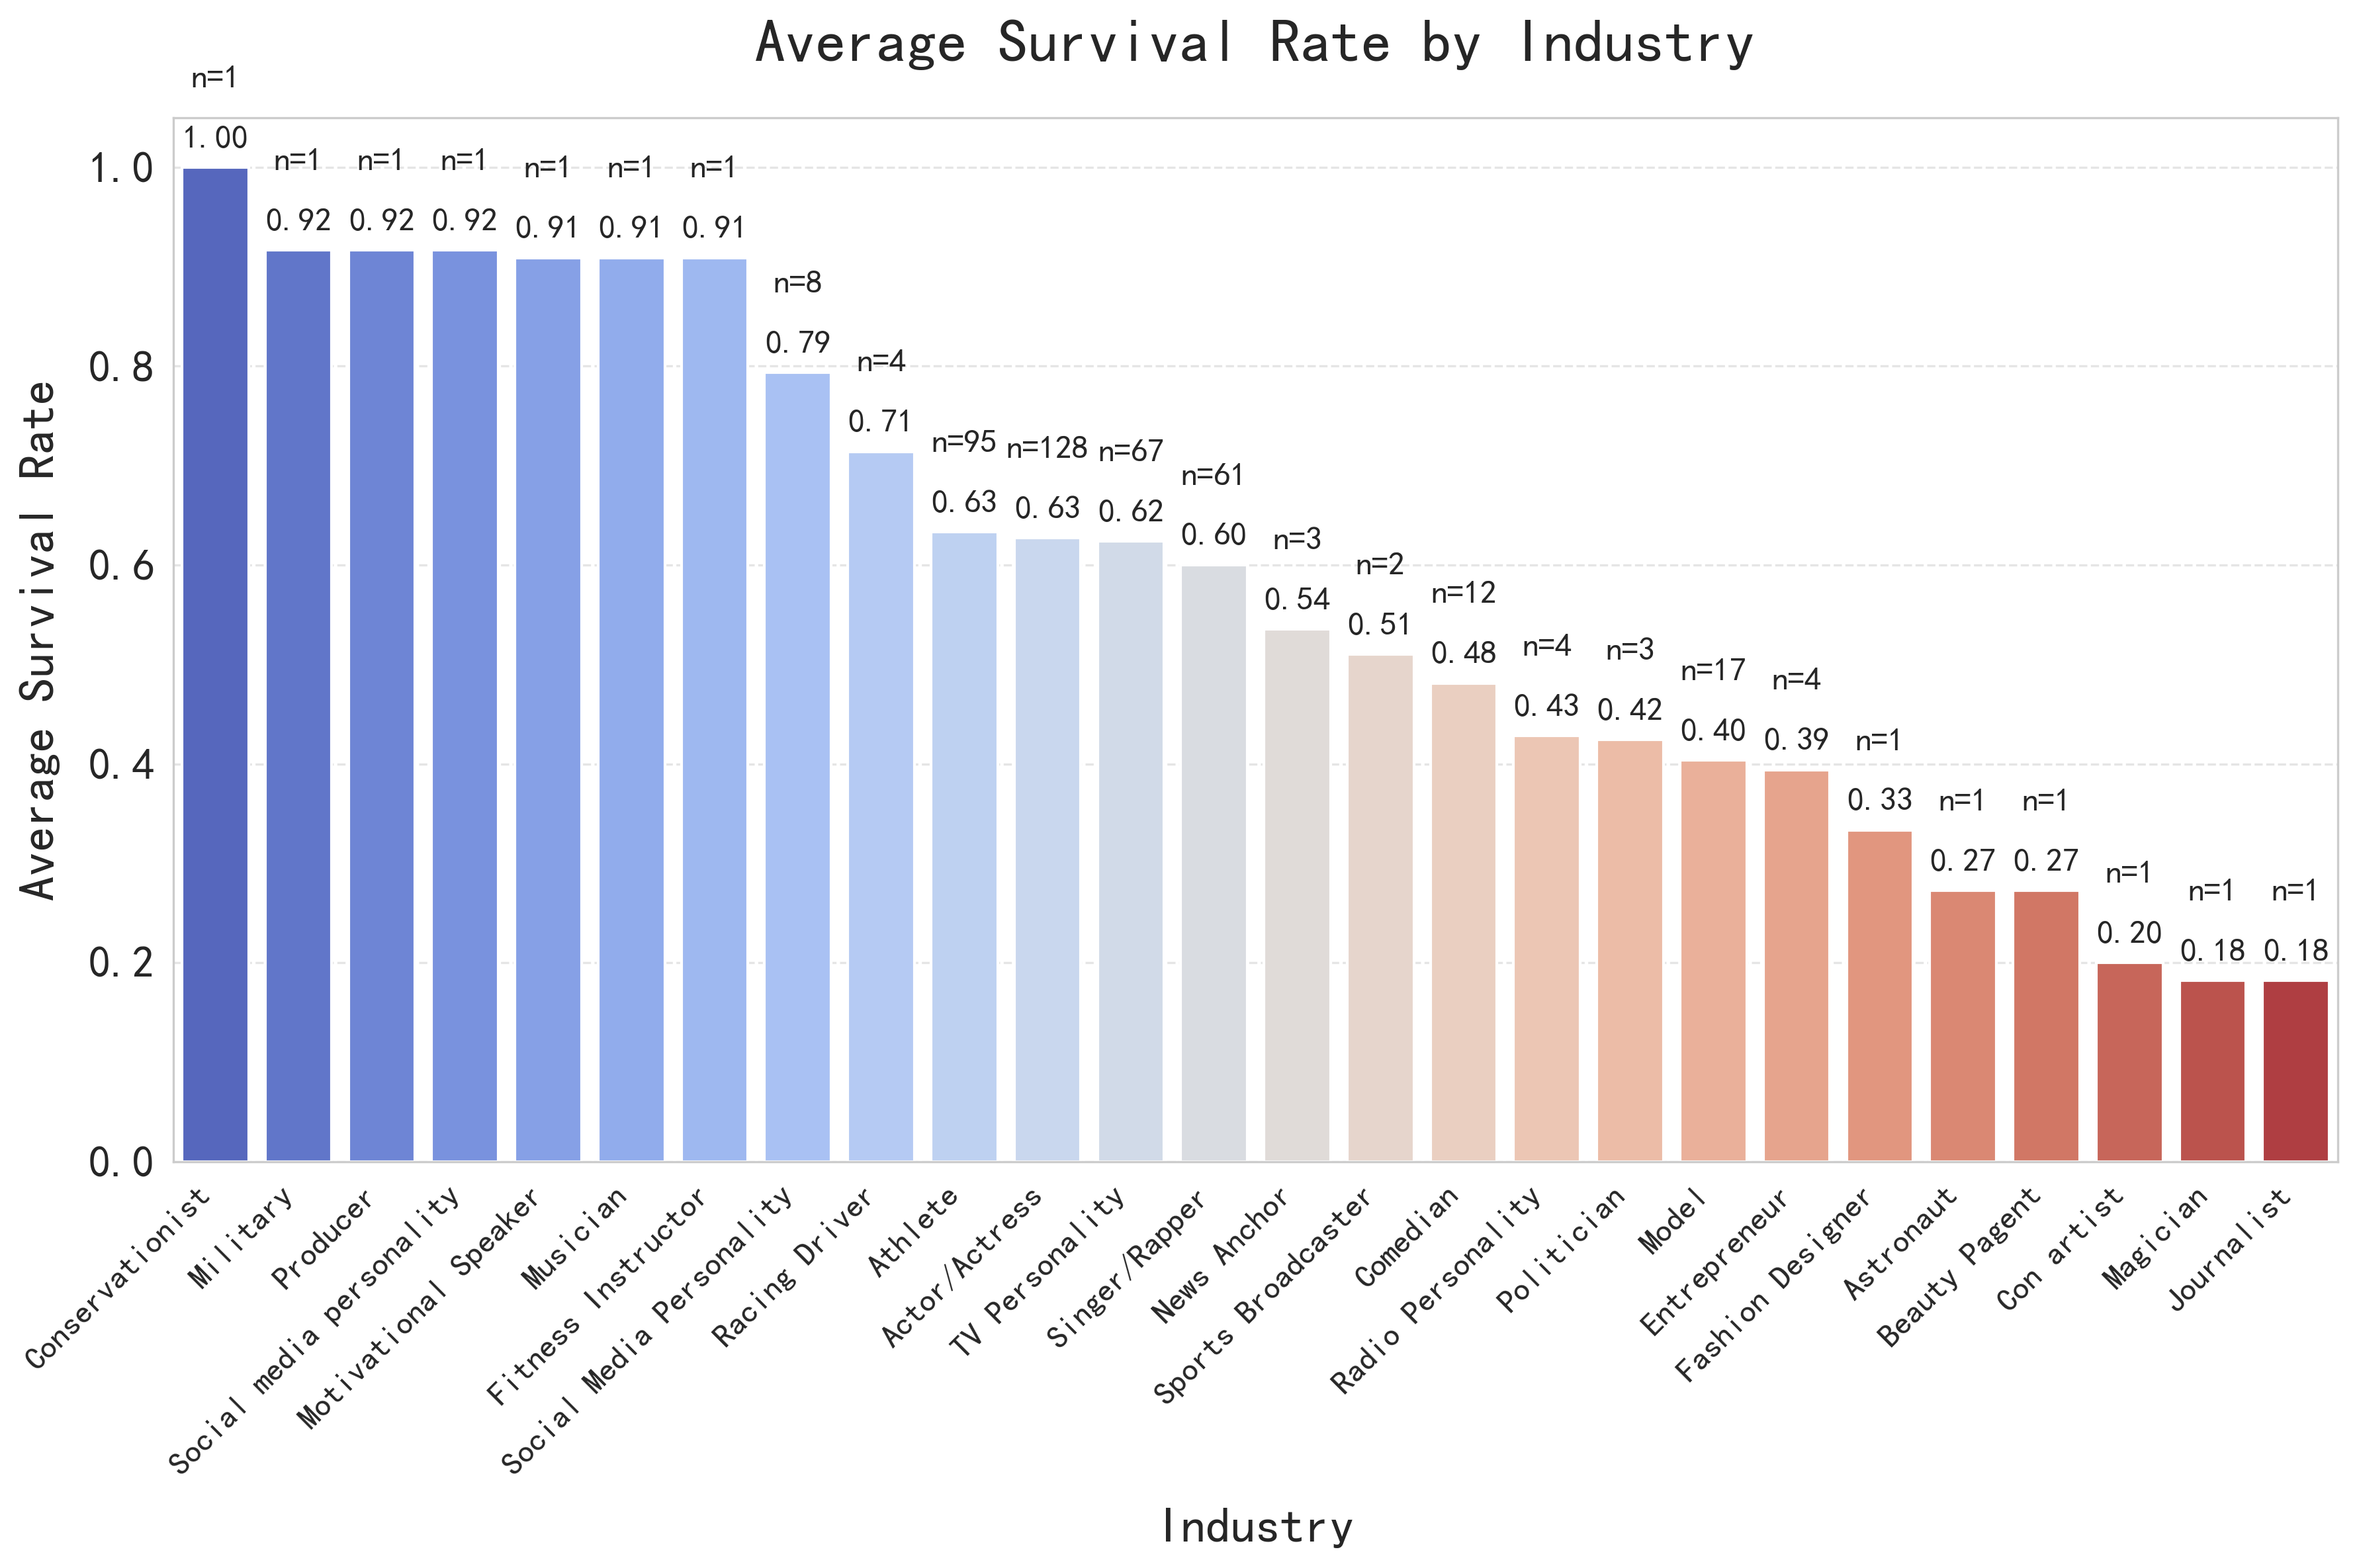

Top 5 Industries by Survival Rate:
         celebrity_industry  survival_rate  count
0           Conservationist           1.00      1
1                  Military           0.92      1
2                  Producer           0.92      1
3  Social media personality           0.92      1
4      Motivational Speaker           0.91      1

Bottom 5 Industries by Survival Rate:
   celebrity_industry  survival_rate  count
21          Astronaut           0.27      1
22      Beauty Pagent           0.27      1
23         Con artist           0.20      1
24           Magician           0.18      1
25         Journalist           0.18      1


In [26]:
# 确保final_week列已合并到df_long（如果未合并）
if 'final_week' not in df_long.columns:
    df_long = df_long.merge(
        source_data[['season', 'final_week']].drop_duplicates(),
        on='season',
        how='left'
    )

# 计算每个选手的存活周数
df_long['survival_weeks'] = df_long.apply(
    lambda row: row['final_week'] if row['is_winner'] else row['elim_week'],
    axis=1
)

# 计算存活率
df_long['survival_rate'] = df_long['survival_weeks'] / df_long['final_week']

# 按职业分组计算平均存活率
industry_survival = df_long.groupby('celebrity_industry')['survival_rate'].mean().reset_index()
industry_survival = industry_survival.sort_values('survival_rate', ascending=False)

# 计算各职业人数
industry_count = source_data.groupby('celebrity_industry').size().reset_index(name='count')
industry_survival = industry_survival.merge(industry_count, on='celebrity_industry')

# 绘制柱状图
plt.figure(figsize=(12, 8),dpi=300)
ax = sns.barplot(
    x='celebrity_industry',
    y='survival_rate',
    data=industry_survival,
    palette="coolwarm",
    order=industry_survival['celebrity_industry']
)

# 添加数据标签 - 存活率
for i, v in enumerate(industry_survival['survival_rate']):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=12)

# 添加人数标签 - 在存活率标签上方
for i, row in enumerate(industry_survival.itertuples()):
    ax.text(i, row.survival_rate + 0.08, f'n={row.count}', ha='center', fontsize=12)

plt.title('Average Survival Rate by Industry', fontsize=22, pad=20)
plt.xlabel('Industry', fontsize=18, labelpad=10)
plt.ylabel('Average Survival Rate', fontsize=18, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 保存高清图片
plt.savefig('industry_survival_rate.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印关键数据
print("Top 5 Industries by Survival Rate:")
print(industry_survival.head(5).round(2))
print("\nBottom 5 Industries by Survival Rate:")
print(industry_survival.tail(5).round(2))
